In [4]:
"""
CREDIT CARD DATA PREPROCESSING
For Interim-1 Submission
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print("="*60)
print("CREDIT CARD DATA PREPROCESSING")
print("="*60)

# Load data
print("\n1. LOADING DATA...")
credit_df = pd.read_csv('data/raw/creditcard.csv')
print(f"✓ Dataset shape: {credit_df.shape}")

# Check data quality
print("\n2. DATA QUALITY CHECK...")
print(f"  Missing values: {credit_df.isnull().sum().sum()}")
print(f"  Duplicates: {credit_df.duplicated().sum()}")

# Remove duplicates if any
if credit_df.duplicated().sum() > 0:
    credit_df = credit_df.drop_duplicates()
    print(f"  ✓ Removed duplicates, new shape: {credit_df.shape}")

# Class imbalance
print("\n3. CLASS IMBALANCE:")
class_dist = credit_df['Class'].value_counts()
print(f"  Class 0 (Legitimate): {class_dist[0]:,} ({class_dist[0]/len(credit_df)*100:.2f}%)")
print(f"  Class 1 (Fraud): {class_dist[1]:,} ({class_dist[1]/len(credit_df)*100:.4f}%)")
print(f"  Imbalance ratio: {class_dist[0]/class_dist[1]:.1f}:1")

# Create time features
print("\n4. ENGINEERING TIME FEATURES...")
credit_df['hour_of_day'] = (credit_df['Time'] / 3600) % 24
credit_df['day_of_week'] = (credit_df['Time'] / (3600 * 24)) % 7
credit_df['is_weekend'] = credit_df['day_of_week'].isin([5, 6]).astype(int)
credit_df['is_night'] = ((credit_df['hour_of_day'] >= 22) | (credit_df['hour_of_day'] <= 6)).astype(int)
print(f"  ✓ Added: hour_of_day, day_of_week, is_weekend, is_night")

# Create amount features
print("\n5. ENGINEERING AMOUNT FEATURES...")
credit_df['log_amount'] = np.log1p(credit_df['Amount'])
credit_df['is_zero_amount'] = (credit_df['Amount'] == 0).astype(int)
print(f"  ✓ Added: log_amount, is_zero_amount")
print(f"  Amount range: ${credit_df['Amount'].min():.2f} to ${credit_df['Amount'].max():.2f}")

# Scale features
print("\n6. SCALING FEATURES...")
pca_cols = [f'V{i}' for i in range(1, 29)]
features_to_scale = ['Time', 'Amount'] + pca_cols

scaler = StandardScaler()
credit_df_scaled = credit_df.copy()
credit_df_scaled[features_to_scale] = scaler.fit_transform(credit_df[features_to_scale])
print(f"  ✓ Scaled {len(features_to_scale)} features")

# Save processed data
print("\n7. SAVING PROCESSED DATA...")
credit_df.to_csv('data/processed/creditcard_enriched.csv', index=False)
credit_df_scaled.to_csv('data/processed/creditcard_scaled.csv', index=False)
joblib.dump(scaler, 'models/scaler_creditcard.pkl')
print("  ✓ Saved: creditcard_enriched.csv")
print("  ✓ Saved: creditcard_scaled.csv")
print("  ✓ Saved: scaler_creditcard.pkl")

print("\n✅ Credit card preprocessing complete!")

CREDIT CARD DATA PREPROCESSING

1. LOADING DATA...
✓ Dataset shape: (284807, 31)

2. DATA QUALITY CHECK...
  Missing values: 0
  Duplicates: 1081
  ✓ Removed duplicates, new shape: (283726, 31)

3. CLASS IMBALANCE:
  Class 0 (Legitimate): 283,253 (99.83%)
  Class 1 (Fraud): 473 (0.1667%)
  Imbalance ratio: 598.8:1

4. ENGINEERING TIME FEATURES...
  ✓ Added: hour_of_day, day_of_week, is_weekend, is_night

5. ENGINEERING AMOUNT FEATURES...
  ✓ Added: log_amount, is_zero_amount
  Amount range: $0.00 to $25691.16

6. SCALING FEATURES...
  ✓ Scaled 30 features

7. SAVING PROCESSED DATA...


NameError: name 'joblib' is not defined

In [5]:
"""
CREDIT CARD DATA PREPROCESSING
For Interim-1 Submission - CORRECTED VERSION
"""

import pandas as pd
import numpy as np
import os
import joblib  # ADD THIS IMPORT
from sklearn.preprocessing import StandardScaler, RobustScaler
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

print("="*60)
print("CREDIT CARD DATA PREPROCESSING")
print("="*60)

# ============================================
# 1. FIND AND LOAD DATA
# ============================================
print("\n1. LOADING DATA...")

# Try multiple possible paths
paths_to_try = [
    'data/raw/creditcard.csv',
    '../data/raw/creditcard.csv',
    './data/raw/creditcard.csv',
    'creditcard.csv'
]

creditcard_filepath = None
for path in paths_to_try:
    if os.path.exists(path):
        creditcard_filepath = path
        print(f"✓ Found file at: {path}")
        break

if creditcard_filepath is None:
    print("✗ Could not find creditcard.csv")
    print("Current directory:", os.getcwd())
    print("Files in current directory:", os.listdir())
    raise FileNotFoundError("creditcard.csv not found")

# Load the data
credit_df = pd.read_csv(creditcard_filepath)
print(f"✓ Dataset loaded successfully!")
print(f"  Shape: {credit_df.shape}")
print(f"  Columns: {len(credit_df.columns)}")

# ============================================
# 2. DATA QUALITY CHECK
# ============================================
print("\n2. DATA QUALITY CHECK...")

# Check missing values
missing = credit_df.isnull().sum().sum()
print(f"  Missing values: {missing}")
if missing == 0:
    print("  ✓ No missing values found")

# Check duplicates
duplicates = credit_df.duplicated().sum()
print(f"  Duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"  ✓ Removing {duplicates} duplicates...")
    credit_df = credit_df.drop_duplicates()
    print(f"  New shape: {credit_df.shape}")

# ============================================
# 3. CLASS IMBALANCE ANALYSIS
# ============================================
print("\n3. CLASS IMBALANCE ANALYSIS...")

class_dist = credit_df['Class'].value_counts()
fraud_rate = class_dist[1] / len(credit_df) * 100

print(f"  Class 0 (Legitimate): {class_dist[0]:,} ({class_dist[0]/len(credit_df)*100:.2f}%)")
print(f"  Class 1 (Fraud): {class_dist[1]:,} ({fraud_rate:.4f}%)")
print(f"  Imbalance ratio: {class_dist[0]/class_dist[1]:.1f}:1")
print(f"  ⚠️ This is HIGHLY IMBALANCED data!")

# ============================================
# 4. TIME FEATURE ENGINEERING
# ============================================
print("\n4. ENGINEERING TIME FEATURES...")

# Time is in seconds from first transaction
print(f"  Time range: {credit_df['Time'].min()} to {credit_df['Time'].max()} seconds")
print(f"  Time span: {(credit_df['Time'].max() - credit_df['Time'].min())/3600:.1f} hours")

# Create time-based features
credit_df['hour_of_day'] = (credit_df['Time'] / 3600) % 24
credit_df['day_of_week'] = (credit_df['Time'] / (3600 * 24)) % 7
credit_df['is_weekend'] = credit_df['day_of_week'].isin([5, 6]).astype(int)
credit_df['is_night'] = ((credit_df['hour_of_day'] >= 22) | (credit_df['hour_of_day'] <= 6)).astype(int)
credit_df['is_business_hours'] = ((credit_df['hour_of_day'] >= 9) & (credit_df['hour_of_day'] <= 17)).astype(int)

print(f"  ✓ Created time features:")
print(f"    - hour_of_day, day_of_week")
print(f"    - is_weekend, is_night, is_business_hours")

# ============================================
# 5. AMOUNT FEATURE ENGINEERING
# ============================================
print("\n5. ENGINEERING AMOUNT FEATURES...")

print(f"  Amount statistics:")
print(f"    Min: ${credit_df['Amount'].min():.2f}")
print(f"    Max: ${credit_df['Amount'].max():.2f}")
print(f"    Mean: ${credit_df['Amount'].mean():.2f}")
print(f"    Median: ${credit_df['Amount'].median():.2f}")

# Create amount features
credit_df['log_amount'] = np.log1p(credit_df['Amount'])  # Log transform
credit_df['is_zero_amount'] = (credit_df['Amount'] == 0).astype(int)
credit_df['is_small_amount'] = (credit_df['Amount'] < 50).astype(int)
credit_df['is_large_amount'] = (credit_df['Amount'] > 500).astype(int)

# Amount categories
credit_df['amount_category'] = pd.cut(credit_df['Amount'], 
                                       bins=[-1, 50, 100, 500, 1000, 5000, float('inf')],
                                       labels=['micro', 'small', 'medium', 'large', 'very_large', 'huge'])

print(f"  ✓ Created amount features:")
print(f"    - log_amount, is_zero_amount, is_small_amount, is_large_amount")
print(f"    - amount_category")

# ============================================
# 6. CREATE SCALED VERSIONS
# ============================================
print("\n6. CREATING SCALED VERSIONS...")

# Features to scale (PCA features V1-V28 are already scaled)
features_to_scale = ['Time', 'Amount']

print(f"  Features to scale: {features_to_scale}")

# Version 1: StandardScaler
scaler_standard = StandardScaler()
credit_df_standard = credit_df.copy()
credit_df_standard[features_to_scale] = scaler_standard.fit_transform(credit_df[features_to_scale])

# Version 2: RobustScaler (less sensitive to outliers)
scaler_robust = RobustScaler()
credit_df_robust = credit_df.copy()
credit_df_robust[features_to_scale] = scaler_robust.fit_transform(credit_df[features_to_scale])

print(f"  ✓ Created scaled versions")
print(f"    - StandardScaler (mean=0, std=1)")
print(f"    - RobustScaler (median=0, IQR-based)")

# ============================================
# 7. SAVE PROCESSED DATA
# ============================================
print("\n7. SAVING PROCESSED DATA...")

# Create directories if they don't exist
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Save enriched data (with features, not scaled)
credit_df.to_csv('data/processed/creditcard_enriched.csv', index=False)
print("  ✓ Saved: data/processed/creditcard_enriched.csv")

# Save scaled versions
credit_df_standard.to_csv('data/processed/creditcard_standard_scaled.csv', index=False)
print("  ✓ Saved: data/processed/creditcard_standard_scaled.csv")

credit_df_robust.to_csv('data/processed/creditcard_robust_scaled.csv', index=False)
print("  ✓ Saved: data/processed/creditcard_robust_scaled.csv")

# Save scalers
joblib.dump(scaler_standard, 'models/scaler_creditcard_standard.pkl')
joblib.dump(scaler_robust, 'models/scaler_creditcard_robust.pkl')
print("  ✓ Saved: models/scaler_creditcard_standard.pkl")
print("  ✓ Saved: models/scaler_creditcard_robust.pkl")

# Save feature correlation with target
correlations = credit_df.corr()['Class'].sort_values(ascending=False)
correlations_df = pd.DataFrame({'feature': correlations.index, 'correlation': correlations.values})
correlations_df.to_csv('data/processed/creditcard_correlations.csv', index=False)
print("  ✓ Saved: data/processed/creditcard_correlations.csv")

# ============================================
# 8. GENERATE SUMMARY VISUALIZATIONS
# ============================================
print("\n8. GENERATING SUMMARY VISUALIZATIONS...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Class distribution
ax1 = axes[0,0]
class_dist.plot(kind='bar', color=['green', 'red'], ax=ax1)
ax1.set_title('Class Distribution', fontweight='bold', fontsize=12)
ax1.set_xlabel('Class (0=Legitimate, 1=Fraud)')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)
# Add value labels
for i, v in enumerate(class_dist.values):
    ax1.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Amount distribution by class
ax2 = axes[0,1]
for class_val, color, label in zip([0,1], ['green', 'red'], ['Legitimate', 'Fraud']):
    subset = credit_df[credit_df['Class'] == class_val]['Amount']
    ax2.hist(subset, bins=50, alpha=0.5, color=color, label=label, edgecolor='black')
ax2.set_title('Transaction Amount Distribution', fontweight='bold', fontsize=12)
ax2.set_xlabel('Amount ($)')
ax2.set_ylabel('Frequency')
ax2.set_yscale('log')
ax2.legend()

# Plot 3: Fraud rate by hour
ax3 = axes[1,0]
fraud_by_hour = credit_df.groupby('hour_of_day')['Class'].mean()
ax3.plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', color='red', linewidth=2, markersize=4)
ax3.set_title('Fraud Rate by Hour of Day', fontweight='bold', fontsize=12)
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Fraud Rate')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, fraud_by_hour.max() * 1.1)

# Plot 4: Top 10 feature correlations
ax4 = axes[1,1]
top_corr = correlations.drop('Class').head(10)
colors = ['red' if x > 0 else 'blue' for x in top_corr.values]
ax4.barh(range(len(top_corr)), top_corr.values, color=colors)
ax4.set_yticks(range(len(top_corr)))
ax4.set_yticklabels(top_corr.index)
ax4.set_title('Top 10 Features Correlated with Fraud', fontweight='bold', fontsize=12)
ax4.set_xlabel('Correlation')
ax4.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('data/processed/creditcard_eda_summary.png', dpi=100, bbox_inches='tight')
plt.show()

print("  ✓ Saved: data/processed/creditcard_eda_summary.png")

# ============================================
# 9. FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("CREDIT CARD PREPROCESSING COMPLETE")
print("="*60)

print("\n📊 FINAL DATASET STATISTICS:")
print(f"  Total transactions: {len(credit_df):,}")
print(f"  Total features: {len(credit_df.columns)}")
print(f"  Original features: 31")
print(f"  New engineered features: {len(credit_df.columns) - 31}")

print("\n🔧 NEW FEATURES CREATED:")
time_features = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'is_business_hours']
amount_features = ['log_amount', 'is_zero_amount', 'is_small_amount', 'is_large_amount', 'amount_category']
print(f"  Time features: {', '.join(time_features)}")
print(f"  Amount features: {', '.join(amount_features)}")

print("\n💾 SAVED FILES:")
print("  • data/processed/creditcard_enriched.csv")
print("  • data/processed/creditcard_standard_scaled.csv")
print("  • data/processed/creditcard_robust_scaled.csv")
print("  • models/scaler_creditcard_standard.pkl")
print("  • models/scaler_creditcard_robust.pkl")
print("  • data/processed/creditcard_correlations.csv")
print("  • data/processed/creditcard_eda_summary.png")

print("\n⚠️ CLASS IMBALANCE STRATEGY (for Task 2):")
print("  → Will use SMOTE on training set only")
print("  → Evaluation: AUC-PR and F1-Score (NOT accuracy)")
print("  → Alternative: Class weights in algorithms")

print("\n✅ Credit card preprocessing complete!")
print("="*60)

# Verify saved files
print("\n📁 VERIFYING SAVED FILES:")
saved_files = [
    'data/processed/creditcard_enriched.csv',
    'data/processed/creditcard_standard_scaled.csv',
    'data/processed/creditcard_robust_scaled.csv',
    'models/scaler_creditcard_standard.pkl',
    'models/scaler_creditcard_robust.pkl'
]

for file in saved_files:
    if os.path.exists(file):
        size = os.path.getsize(file) / (1024 * 1024)
        print(f"  ✓ {file} ({size:.2f} MB)")
    else:
        print(f"  ✗ {file} not found")

print("\n🎉 Ready for Interim-1 submission!")

CREDIT CARD DATA PREPROCESSING

1. LOADING DATA...
✓ Found file at: data/raw/creditcard.csv
✓ Dataset loaded successfully!
  Shape: (284807, 31)
  Columns: 31

2. DATA QUALITY CHECK...
  Missing values: 0
  ✓ No missing values found
  Duplicate rows: 1081
  ✓ Removing 1081 duplicates...
  New shape: (283726, 31)

3. CLASS IMBALANCE ANALYSIS...
  Class 0 (Legitimate): 283,253 (99.83%)
  Class 1 (Fraud): 473 (0.1667%)
  Imbalance ratio: 598.8:1
  ⚠️ This is HIGHLY IMBALANCED data!

4. ENGINEERING TIME FEATURES...
  Time range: 0.0 to 172792.0 seconds
  Time span: 48.0 hours
  ✓ Created time features:
    - hour_of_day, day_of_week
    - is_weekend, is_night, is_business_hours

5. ENGINEERING AMOUNT FEATURES...
  Amount statistics:
    Min: $0.00
    Max: $25691.16
    Mean: $88.47
    Median: $22.00
  ✓ Created amount features:
    - log_amount, is_zero_amount, is_small_amount, is_large_amount
    - amount_category

6. CREATING SCALED VERSIONS...
  Features to scale: ['Time', 'Amount']
 

ValueError: could not convert string to float: 'medium'

CREDIT CARD DATA PREPROCESSING

1. LOADING DATA...
✓ Found file at: data/raw/creditcard.csv
✓ Dataset loaded successfully!
  Shape: (284807, 31)
  Columns: 31

2. DATA QUALITY CHECK...
  Missing values: 0
  ✓ No missing values found
  Duplicate rows: 1081
  ✓ Removing 1081 duplicates...
  New shape: (283726, 31)

3. CLASS IMBALANCE ANALYSIS...
  Class 0 (Legitimate): 283,253 (99.83%)
  Class 1 (Fraud): 473 (0.1667%)
  Imbalance ratio: 598.8:1
  ⚠️ This is HIGHLY IMBALANCED data!

4. ENGINEERING TIME FEATURES...
  Time range: 0.0 to 172792.0 seconds
  Time span: 48.0 hours
  ✓ Created time features:
    - hour_of_day, day_of_week
    - is_weekend, is_night, is_business_hours

5. ENGINEERING AMOUNT FEATURES...
  Amount statistics:
    Min: $0.00
    Max: $25691.16
    Mean: $88.47
    Median: $22.00
  ✓ Created amount features:
    - log_amount, sqrt_amount (numeric transforms)
    - is_zero_amount, is_small_amount, is_large_amount (binary flags)
    - amount_category_code (numeric categ

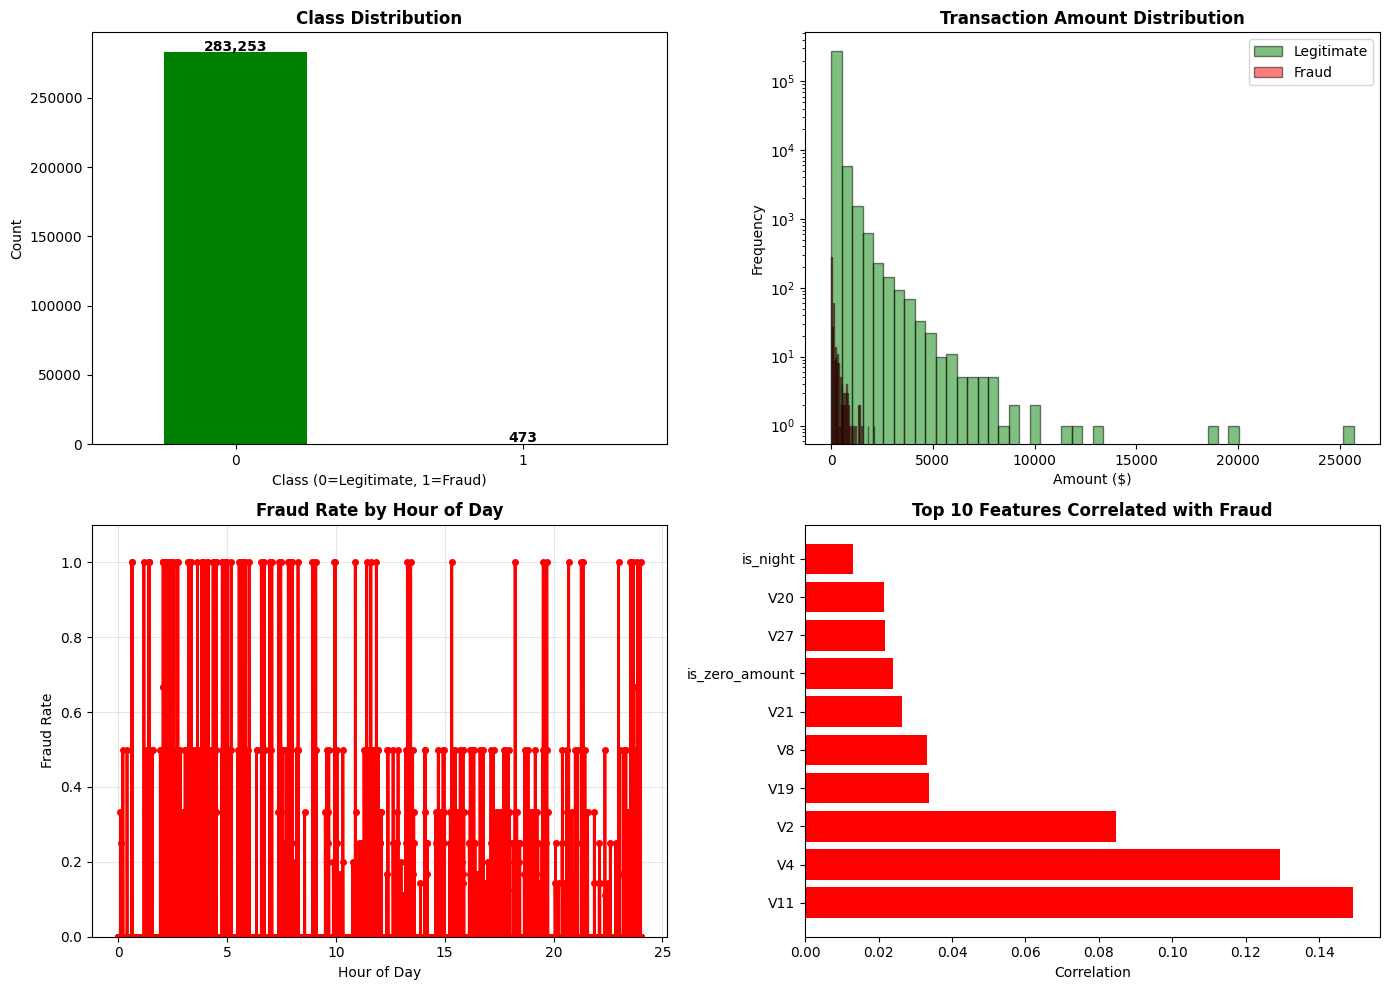

  ✓ Saved: data/processed/creditcard_eda_summary.png

CREDIT CARD PREPROCESSING COMPLETE

📊 FINAL DATASET STATISTICS:
  Total transactions: 283,726
  Total features: 42
  Original features: 31
  New engineered features: 11

🔧 NEW FEATURES CREATED:
  Time features: hour_of_day, day_of_week, is_weekend, is_night, is_business_hours
  Amount features: log_amount, sqrt_amount, is_zero_amount, is_small_amount, is_large_amount, amount_category_code

💾 SAVED FILES:
  • data/processed/creditcard_enriched.csv
  • data/processed/creditcard_standard_scaled.csv
  • data/processed/creditcard_robust_scaled.csv
  • models/scaler_creditcard_standard.pkl
  • models/scaler_creditcard_robust.pkl
  • data/processed/creditcard_correlations.csv
  • data/processed/creditcard_eda_summary.png

📈 KEY INSIGHTS FROM CORRELATION ANALYSIS:
  Features with strongest positive correlation to fraud:
    • V11: 0.1491
    • V4: 0.1293
    • V2: 0.0846
    • V19: 0.0336
    • V8: 0.0331

⚠️ CLASS IMBALANCE STRATEGY (for T

In [6]:
"""
CREDIT CARD DATA PREPROCESSING
For Interim-1 Submission - FIXED VERSION
"""

import pandas as pd
import numpy as np
import os
import joblib
from sklearn.preprocessing import StandardScaler, RobustScaler
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

print("="*60)
print("CREDIT CARD DATA PREPROCESSING")
print("="*60)

# ============================================
# 1. FIND AND LOAD DATA
# ============================================
print("\n1. LOADING DATA...")

# Try multiple possible paths
paths_to_try = [
    'data/raw/creditcard.csv',
    '../data/raw/creditcard.csv',
    './data/raw/creditcard.csv',
    'creditcard.csv'
]

creditcard_filepath = None
for path in paths_to_try:
    if os.path.exists(path):
        creditcard_filepath = path
        print(f"✓ Found file at: {path}")
        break

if creditcard_filepath is None:
    print("✗ Could not find creditcard.csv")
    print("Current directory:", os.getcwd())
    raise FileNotFoundError("creditcard.csv not found")

# Load the data
credit_df = pd.read_csv(creditcard_filepath)
print(f"✓ Dataset loaded successfully!")
print(f"  Shape: {credit_df.shape}")
print(f"  Columns: {len(credit_df.columns)}")

# ============================================
# 2. DATA QUALITY CHECK
# ============================================
print("\n2. DATA QUALITY CHECK...")

# Check missing values
missing = credit_df.isnull().sum().sum()
print(f"  Missing values: {missing}")
if missing == 0:
    print("  ✓ No missing values found")

# Check duplicates
duplicates = credit_df.duplicated().sum()
print(f"  Duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"  ✓ Removing {duplicates} duplicates...")
    credit_df = credit_df.drop_duplicates()
    print(f"  New shape: {credit_df.shape}")

# ============================================
# 3. CLASS IMBALANCE ANALYSIS
# ============================================
print("\n3. CLASS IMBALANCE ANALYSIS...")

class_dist = credit_df['Class'].value_counts()
fraud_rate = class_dist[1] / len(credit_df) * 100

print(f"  Class 0 (Legitimate): {class_dist[0]:,} ({class_dist[0]/len(credit_df)*100:.2f}%)")
print(f"  Class 1 (Fraud): {class_dist[1]:,} ({fraud_rate:.4f}%)")
print(f"  Imbalance ratio: {class_dist[0]/class_dist[1]:.1f}:1")
print(f"  ⚠️ This is HIGHLY IMBALANCED data!")

# ============================================
# 4. TIME FEATURE ENGINEERING
# ============================================
print("\n4. ENGINEERING TIME FEATURES...")

# Time is in seconds from first transaction
print(f"  Time range: {credit_df['Time'].min()} to {credit_df['Time'].max()} seconds")
print(f"  Time span: {(credit_df['Time'].max() - credit_df['Time'].min())/3600:.1f} hours")

# Create time-based features
credit_df['hour_of_day'] = (credit_df['Time'] / 3600) % 24
credit_df['day_of_week'] = (credit_df['Time'] / (3600 * 24)) % 7
credit_df['is_weekend'] = credit_df['day_of_week'].isin([5, 6]).astype(int)
credit_df['is_night'] = ((credit_df['hour_of_day'] >= 22) | (credit_df['hour_of_day'] <= 6)).astype(int)
credit_df['is_business_hours'] = ((credit_df['hour_of_day'] >= 9) & (credit_df['hour_of_day'] <= 17)).astype(int)

print(f"  ✓ Created time features:")
print(f"    - hour_of_day, day_of_week")
print(f"    - is_weekend, is_night, is_business_hours")

# ============================================
# 5. AMOUNT FEATURE ENGINEERING
# ============================================
print("\n5. ENGINEERING AMOUNT FEATURES...")

print(f"  Amount statistics:")
print(f"    Min: ${credit_df['Amount'].min():.2f}")
print(f"    Max: ${credit_df['Amount'].max():.2f}")
print(f"    Mean: ${credit_df['Amount'].mean():.2f}")
print(f"    Median: ${credit_df['Amount'].median():.2f}")

# Create amount features (numeric only - no strings)
credit_df['log_amount'] = np.log1p(credit_df['Amount'])  # Log transform
credit_df['sqrt_amount'] = np.sqrt(credit_df['Amount'])  # Square root transform
credit_df['is_zero_amount'] = (credit_df['Amount'] == 0).astype(int)
credit_df['is_small_amount'] = (credit_df['Amount'] < 50).astype(int)
credit_df['is_large_amount'] = (credit_df['Amount'] > 500).astype(int)

# Keep amount_category for analysis but don't use in correlation
# Convert to numeric codes for potential use
credit_df['amount_category_code'] = pd.cut(credit_df['Amount'], 
                                           bins=[-1, 50, 100, 500, 1000, 5000, float('inf')],
                                           labels=[0, 1, 2, 3, 4, 5]).astype(int)

print(f"  ✓ Created amount features:")
print(f"    - log_amount, sqrt_amount (numeric transforms)")
print(f"    - is_zero_amount, is_small_amount, is_large_amount (binary flags)")
print(f"    - amount_category_code (numeric categories 0-5)")

# ============================================
# 6. CREATE SCALED VERSIONS
# ============================================
print("\n6. CREATING SCALED VERSIONS...")

# Features to scale (Time, Amount, and derived amount features)
features_to_scale = ['Time', 'Amount', 'log_amount', 'sqrt_amount', 'amount_category_code']

print(f"  Features to scale: {features_to_scale}")

# Version 1: StandardScaler
scaler_standard = StandardScaler()
credit_df_standard = credit_df.copy()
credit_df_standard[features_to_scale] = scaler_standard.fit_transform(credit_df[features_to_scale])

# Version 2: RobustScaler (less sensitive to outliers)
scaler_robust = RobustScaler()
credit_df_robust = credit_df.copy()
credit_df_robust[features_to_scale] = scaler_robust.fit_transform(credit_df[features_to_scale])

print(f"  ✓ Created scaled versions")
print(f"    - StandardScaler (mean=0, std=1)")
print(f"    - RobustScaler (median=0, IQR-based)")

# ============================================
# 7. SAVE PROCESSED DATA
# ============================================
print("\n7. SAVING PROCESSED DATA...")

# Create directories if they don't exist
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Save enriched data (with features, not scaled)
credit_df.to_csv('data/processed/creditcard_enriched.csv', index=False)
print("  ✓ Saved: data/processed/creditcard_enriched.csv")

# Save scaled versions
credit_df_standard.to_csv('data/processed/creditcard_standard_scaled.csv', index=False)
print("  ✓ Saved: data/processed/creditcard_standard_scaled.csv")

credit_df_robust.to_csv('data/processed/creditcard_robust_scaled.csv', index=False)
print("  ✓ Saved: data/processed/creditcard_robust_scaled.csv")

# Save scalers
joblib.dump(scaler_standard, 'models/scaler_creditcard_standard.pkl')
joblib.dump(scaler_robust, 'models/scaler_creditcard_robust.pkl')
print("  ✓ Saved: models/scaler_creditcard_standard.pkl")
print("  ✓ Saved: models/scaler_creditcard_robust.pkl")

# ============================================
# 8. CORRELATION ANALYSIS (numeric columns only)
# ============================================
print("\n8. CORRELATION ANALYSIS WITH TARGET...")

# Select only numeric columns for correlation
numeric_cols = credit_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"  Numeric columns for correlation: {len(numeric_cols)}")

# Calculate correlations with Class
correlations = credit_df[numeric_cols].corr()['Class'].sort_values(ascending=False)
print("\n  Top 10 features correlated with fraud (positive):")
for feat, corr in correlations.head(11).items():  # Show top 10 plus Class itself
    if feat != 'Class':
        print(f"    {feat:20s}: {corr:.4f}")

print("\n  Bottom 10 features correlated with fraud (negative):")
for feat, corr in correlations.tail(10).items():
    if feat != 'Class':
        print(f"    {feat:20s}: {corr:.4f}")

# Save correlations
correlations_df = pd.DataFrame({
    'feature': correlations.index, 
    'correlation': correlations.values
})
correlations_df.to_csv('data/processed/creditcard_correlations.csv', index=False)
print("\n  ✓ Saved: data/processed/creditcard_correlations.csv")

# ============================================
# 9. GENERATE SUMMARY VISUALIZATIONS
# ============================================
print("\n9. GENERATING SUMMARY VISUALIZATIONS...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Class distribution
ax1 = axes[0,0]
class_dist.plot(kind='bar', color=['green', 'red'], ax=ax1)
ax1.set_title('Class Distribution', fontweight='bold', fontsize=12)
ax1.set_xlabel('Class (0=Legitimate, 1=Fraud)')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)
# Add value labels
for i, v in enumerate(class_dist.values):
    ax1.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Amount distribution by class
ax2 = axes[0,1]
for class_val, color, label in zip([0,1], ['green', 'red'], ['Legitimate', 'Fraud']):
    subset = credit_df[credit_df['Class'] == class_val]['Amount']
    ax2.hist(subset, bins=50, alpha=0.5, color=color, label=label, edgecolor='black')
ax2.set_title('Transaction Amount Distribution', fontweight='bold', fontsize=12)
ax2.set_xlabel('Amount ($)')
ax2.set_ylabel('Frequency')
ax2.set_yscale('log')
ax2.legend()

# Plot 3: Fraud rate by hour
ax3 = axes[1,0]
fraud_by_hour = credit_df.groupby('hour_of_day')['Class'].mean()
ax3.plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', color='red', linewidth=2, markersize=4)
ax3.set_title('Fraud Rate by Hour of Day', fontweight='bold', fontsize=12)
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Fraud Rate')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, fraud_by_hour.max() * 1.1)

# Plot 4: Top 10 feature correlations (excluding Class)
ax4 = axes[1,1]
top_corr = correlations.drop('Class').head(10)
colors_corr = ['red' if x > 0 else 'blue' for x in top_corr.values]
ax4.barh(range(len(top_corr)), top_corr.values, color=colors_corr)
ax4.set_yticks(range(len(top_corr)))
ax4.set_yticklabels(top_corr.index)
ax4.set_title('Top 10 Features Correlated with Fraud', fontweight='bold', fontsize=12)
ax4.set_xlabel('Correlation')
ax4.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('data/processed/creditcard_eda_summary.png', dpi=100, bbox_inches='tight')
plt.show()

print("  ✓ Saved: data/processed/creditcard_eda_summary.png")

# ============================================
# 10. FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("CREDIT CARD PREPROCESSING COMPLETE")
print("="*60)

print("\n📊 FINAL DATASET STATISTICS:")
print(f"  Total transactions: {len(credit_df):,}")
print(f"  Total features: {len(credit_df.columns)}")
print(f"  Original features: 31")
print(f"  New engineered features: {len(credit_df.columns) - 31}")

print("\n🔧 NEW FEATURES CREATED:")
time_features = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'is_business_hours']
amount_features = ['log_amount', 'sqrt_amount', 'is_zero_amount', 'is_small_amount', 
                   'is_large_amount', 'amount_category_code']
print(f"  Time features: {', '.join(time_features)}")
print(f"  Amount features: {', '.join(amount_features)}")

print("\n💾 SAVED FILES:")
print("  • data/processed/creditcard_enriched.csv")
print("  • data/processed/creditcard_standard_scaled.csv")
print("  • data/processed/creditcard_robust_scaled.csv")
print("  • models/scaler_creditcard_standard.pkl")
print("  • models/scaler_creditcard_robust.pkl")
print("  • data/processed/creditcard_correlations.csv")
print("  • data/processed/creditcard_eda_summary.png")

print("\n📈 KEY INSIGHTS FROM CORRELATION ANALYSIS:")
print("  Features with strongest positive correlation to fraud:")
for feat, corr in top_corr.head(5).items():
    print(f"    • {feat}: {corr:.4f}")

print("\n⚠️ CLASS IMBALANCE STRATEGY (for Task 2):")
print("  → Will use SMOTE on training set only")
print("  → Evaluation: AUC-PR and F1-Score (NOT accuracy)")
print("  → Alternative: Class weights in algorithms")

print("\n✅ Credit card preprocessing complete!")
print("="*60)

# Verify saved files
print("\n📁 VERIFYING SAVED FILES:")
saved_files = [
    'data/processed/creditcard_enriched.csv',
    'data/processed/creditcard_standard_scaled.csv',
    'data/processed/creditcard_robust_scaled.csv',
    'models/scaler_creditcard_standard.pkl',
    'models/scaler_creditcard_robust.pkl',
    'data/processed/creditcard_correlations.csv',
    'data/processed/creditcard_eda_summary.png'
]

for file in saved_files:
    if os.path.exists(file):
        size = os.path.getsize(file) / (1024 * 1024)
        print(f"  ✓ {file} ({size:.2f} MB)")
    else:
        print(f"  ✗ {file} not found")

print("\n🎉 Ready for Interim-1 submission!")